In [1]:
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())

2.10.0
True


In [10]:
import pandas as pd

df = pd.read_excel("~/Downloads/credit_data.xls", header=1)

y = df["default payment next month"].values
df = df.drop("default payment next month", axis=1)
X = df.drop("ID", axis=1).values
print("input data", X)
print("y target data",y)

input data [[ 20000      2      2 ...      0      0      0]
 [120000      2      2 ...   1000      0   2000]
 [ 90000      2      2 ...   1000   1000   5000]
 ...
 [ 30000      1      2 ...   4200   2000   3100]
 [ 80000      1      3 ...   1926  52964   1804]
 [ 50000      1      2 ...   1000   1000   1000]]
y target data [1 1 0 ... 1 1 1]


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
# splitting dataset into training, cross_validation, and test datasets

# split train and test into 80/20
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# split train into train and cv into 64/16
X_train, X_cv, y_train, y_cv = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

del X_train_full, y_train_full

print(f"the shape of the training set (input) is: {X_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {X_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {X_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (19200, 23)
the shape of the training set (target) is: (19200,)

the shape of the cross validation set (input) is: (4800, 23)
the shape of the cross validation set (target) is: (4800,)

the shape of the test set (input) is: (6000, 23)
the shape of the test set (target) is: (6000,)


In [16]:
# Initialize the class , scaling features to improve run time of gradient descent
scaler_linear = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
X_train_scaled = scaler_linear.fit_transform(X_train)
X_cv_scaled = scaler_linear.fit_transform(X_cv)
X_test_scaled = scaler_linear.fit_transform(X_test)

# check scaled data
print(f"the data x_train after scaling: {X_train_scaled}")

the data x_train after scaling: [[-0.82536454 -1.23021055 -1.07712006 ... -0.19707667 -0.20523623
  -0.20418613]
 [ 0.94122695  0.81286899 -1.07712006 ...  0.58183549  0.19314754
   1.04071658]
 [ 0.94122695 -1.23021055  1.44199866 ... -0.29008111 -0.28033195
  -0.27469988]
 ...
 [-1.13259784 -1.23021055 -1.07712006 ... -0.25183303 -0.23388362
  -0.29583682]
 [-1.05578952  0.81286899  0.1824393  ... -0.17382556 -0.17971517
  -0.29583682]
 [ 1.0948436   0.81286899  0.1824393  ...  0.03479502  0.07453841
   0.24157989]]


In [22]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_cv_tensor = torch.tensor(X_cv_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_cv_tensor = torch.tensor(y_cv, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_cv_tensor:", X_cv_tensor.shape)
print("y_cv_tensor:", y_cv_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([19200, 23])
y_train_tensor: torch.Size([19200, 1])
X_cv_tensor: torch.Size([4800, 23])
y_cv_tensor: torch.Size([4800, 1])
X_test_tensor: torch.Size([6000, 23])
y_test_tensor: torch.Size([6000, 1])


In [23]:
print(X_train_tensor[:2])
print(y_train_tensor[:2])

tensor([[-0.8254, -1.2302, -1.0771, -1.0507,  0.2640,  1.7821,  1.7711,  1.8096,
          0.1843,  0.2306,  0.2482,  0.1088,  0.1575,  0.1677,  0.0967, -0.0336,
         -0.0116, -0.1722, -0.2334, -0.1697, -0.1971, -0.2052, -0.2042],
        [ 0.9412,  0.8129, -1.0771,  0.8602, -1.1371,  0.0126,  0.1067,  0.1367,
          0.1843,  0.2306,  0.2482,  3.4413,  3.5578,  3.5585,  3.1926,  3.2886,
          3.2006,  0.5340,  0.1762,  0.2553,  0.5818,  0.1931,  1.0407]])
tensor([[0.],
        [1.]])


In [25]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
cv_dataset = TensorDataset(X_cv_tensor, y_cv_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print(len(train_dataset))

19200


In [26]:
print("Train dataset size:", len(train_dataset))
print("CV dataset size:", len(cv_dataset))
print("Test dataset size:", len(test_dataset))

x_sample, y_sample = train_dataset[0]

print("\nSample feature shape:", x_sample.shape)
print("Sample label:", y_sample)

Train dataset size: 19200
CV dataset size: 4800
Test dataset size: 6000

Sample feature shape: torch.Size([23])
Sample label: tensor([0.])


In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
cv_loader = DataLoader(cv_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [28]:
X_batch, y_batch = next(iter(train_loader))

print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)

print("\nFirst batch features:")
print(X_batch[:2])

print("\nFirst batch labels:")
print(y_batch[:2])

X_batch shape: torch.Size([32, 23])
y_batch shape: torch.Size([32, 1])

First batch features:
tensor([[-0.8254,  0.8129,  0.1824, -1.0507,  1.7728,  0.8974,  1.7711,  0.1367,
          0.1843,  0.2306,  0.2482, -0.3019, -0.3089, -0.2743, -0.2298, -0.1955,
         -0.1728, -0.3272, -0.1757, -0.2050, -0.2318, -0.2416, -0.2339],
        [-0.7486,  0.8129, -1.0771,  0.8602, -0.9215, -0.8721, -0.7255, -0.6998,
         -0.6679, -0.6497, -0.6178, -0.6909, -0.6859, -0.6683, -0.6674, -0.6559,
         -0.6434, -0.3182, -0.2273, -0.2742, -0.2722, -0.2750, -0.2754]])

First batch labels:
tensor([[0.],
        [0.]])


In [39]:
import torch
import torch.nn as nn

class CreditDefaultNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [40]:
input_dim = X_train_tensor.shape[1]
model = CreditDefaultNet(input_dim)

print(model)

CreditDefaultNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [41]:
X_batch, y_batch = next(iter(train_loader))

logits = model(X_batch)

print("Input batch shape:", X_batch.shape)
print("Output logits shape:", logits.shape)

probs = torch.sigmoid(logits)

Input batch shape: torch.Size([32, 23])
Output logits shape: torch.Size([32, 1])


In [43]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss = criterion(logits, y_batch)

print("X_batch device:", X_batch.device)
print("y_batch device:", y_batch.device)
print("logits shape:", logits.shape)
print("loss:", loss.item())

Using device: mps
X_batch device: cpu
y_batch device: cpu
logits shape: torch.Size([32, 1])
loss: 0.6070811748504639


In [46]:
epochs=50
patience=10

cv_losses=[]
train_losses=[]


best_cv_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits=model(X_batch)
        
        loss = criterion(logits,y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    running_cv_loss = 0.0
    
    with torch.no_grad():
        for X_cv, y_cv in cv_loader:
            X_cv = X_cv.to(device)
            y_cv = y_cv.to(device)

            logits=model(X_cv)
            loss = criterion(logits, y_cv)

            running_cv_loss += loss.item() * X_cv.size(0)
    epoch_cv_loss = running_cv_loss/len(cv_loader.dataset)
    cv_losses.append(epoch_cv_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | CV Loss: {epoch_cv_loss:.4f}")

    if epoch_cv_loss < best_cv_loss:
        best_cv_loss = epoch_cv_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict()
    else:
        epochs_without_improvement +=1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)    

Epoch 1/50 | Train Loss: 0.4369 | CV Loss: 0.4443
Epoch 2/50 | Train Loss: 0.4328 | CV Loss: 0.4425
Epoch 3/50 | Train Loss: 0.4299 | CV Loss: 0.4471
Epoch 4/50 | Train Loss: 0.4282 | CV Loss: 0.4445
Epoch 5/50 | Train Loss: 0.4270 | CV Loss: 0.4415
Epoch 6/50 | Train Loss: 0.4263 | CV Loss: 0.4397
Epoch 7/50 | Train Loss: 0.4253 | CV Loss: 0.4402
Epoch 8/50 | Train Loss: 0.4243 | CV Loss: 0.4428
Epoch 9/50 | Train Loss: 0.4237 | CV Loss: 0.4413
Epoch 10/50 | Train Loss: 0.4231 | CV Loss: 0.4421
Epoch 11/50 | Train Loss: 0.4220 | CV Loss: 0.4425
Epoch 12/50 | Train Loss: 0.4213 | CV Loss: 0.4426
Epoch 13/50 | Train Loss: 0.4212 | CV Loss: 0.4412
Epoch 14/50 | Train Loss: 0.4207 | CV Loss: 0.4404
Epoch 15/50 | Train Loss: 0.4204 | CV Loss: 0.4412
Epoch 16/50 | Train Loss: 0.4195 | CV Loss: 0.4405
Early stopping triggered at epoch 16


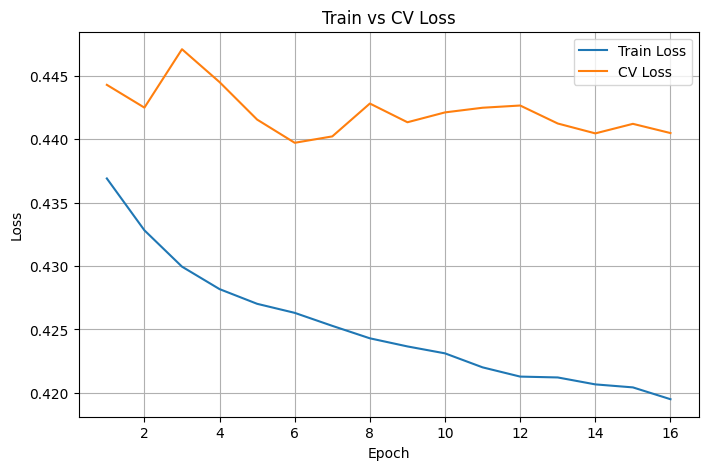

In [48]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, cv_losses, label="CV Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs CV Loss")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)

        all_logits.append(logits.cpu())
        all_labels.append(y_batch.cpu())

# Combine all batches into full test tensors
all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Convert logits to probabilities
y_probs = torch.sigmoid(all_logits).numpy().flatten()

# Convert true labels to numpy
y_true = all_labels.numpy().flatten()

# Apply threshold
threshold = 0.3
y_pred = (y_probs >= threshold).astype(int)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_probs)

print(f"Threshold: {threshold}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Threshold: 0.3
Accuracy:  0.7797
Precision: 0.4970
Recall:    0.5659
F1 Score:  0.5292
ROC-AUC:   0.7679

Confusion Matrix:
[[3935  752]
 [ 570  743]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.84      0.86      4687
         1.0       0.50      0.57      0.53      1313

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

